[OK] Required variables found in memory — no retraining needed for the base models.

STEP 1: SMOTE (Clinical / Tabular)
Before SMOTE: {0: 131, 1: 111}
After  SMOTE: {1: 131, 0: 131}
[OK] SMOTE-balanced clinical model trained (23 epochs, quick).

[CLINICAL (original)] Acc=0.8525 Prec=0.8276 Rec=0.8571 F1=0.8421 AUC=0.9426 AP=0.9366

[CLINICAL (SMOTE)] Acc=0.8689 Prec=0.8333 Rec=0.8929 F1=0.8621 AUC=0.9437 AP=0.9285

STEP 2: PRECISION-RECALL CURVES


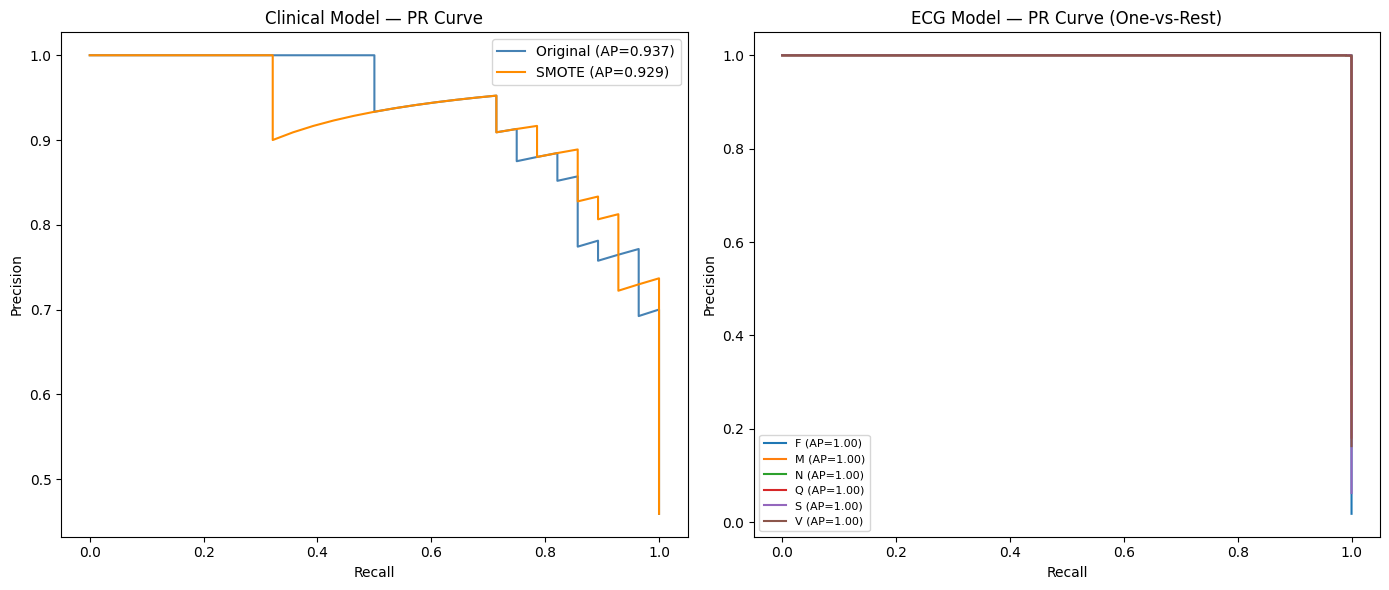


STEP 3: SHAP (Clinical model)


  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\USER\AppData\Local\Temp\ipykernel_9192\4098021216.py:161: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, feature_names=feature_cols, show=False)


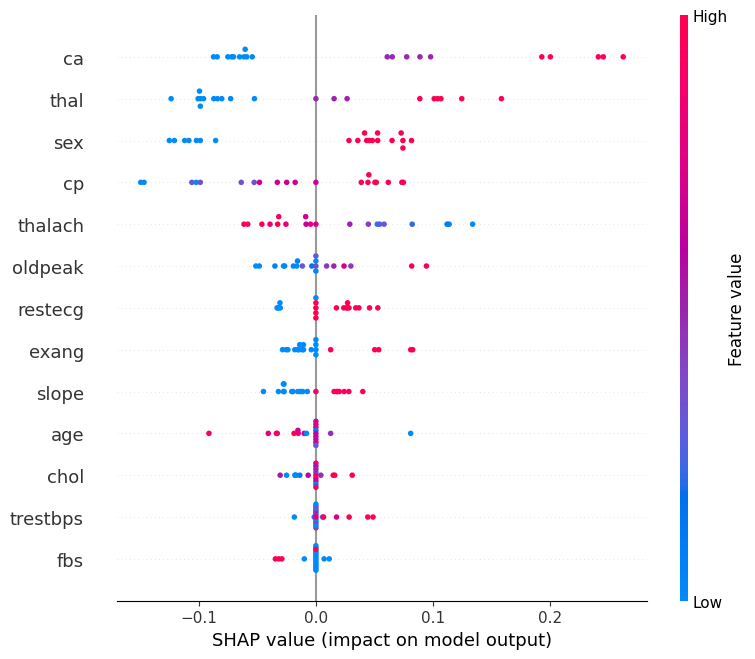

[OK] SHAP summary plot saved -> shap_summary.png

STEP 4: LIME (Clinical model, single instance)


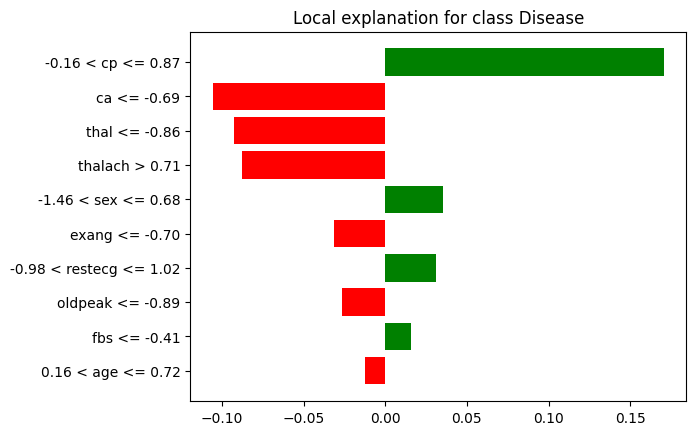

[OK] LIME explanation (test row 0) saved -> lime_explanation.png
Top features driving this prediction:
   -0.16 < cp <= 0.87: +0.1705
   ca <= -0.69: -0.1056
   thal <= -0.86: -0.0928
   thalach > 0.71: -0.0880
   -1.46 < sex <= 0.68: +0.0352
   exang <= -0.70: -0.0316
   -0.98 < restecg <= 1.02: +0.0313
   oldpeak <= -0.89: -0.0264
   fbs <= -0.41: +0.0157
   0.16 < age <= 0.72: -0.0127

SUMMARY — ALL METRICS
              Model  Accuracy  Precision  Recall     F1    AUC     AP
Clinical (original)    0.8525     0.8276  0.8571 0.8421 0.9426 0.9366
   Clinical (SMOTE)    0.8689     0.8333  0.8929 0.8621 0.9437 0.9285

[OK] DONE — new files saved:
  pr_curves.png
  shap_summary.png
  lime_explanation.png


In [6]:

# (y_prob_ecg / y_true_ecg) reuse kora hoise, tai eta INSTANT.
# ==============================================================

# ---- 0) SAFETY CHECK: main cell run kora ache to na? ----
_required = ["scaler", "feature_cols", "X_train_s", "X_test_s", "y_train", "y_test",
             "clinical_model", "ecg_model", "ecg_class_names", "NORMAL_CLASS_INDEX",
             "NUM_CLASSES", "test_gen"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        "Age main cell (PART 1 + PART 2) run koro age! Missing variables: "
        + ", ".join(_missing)
    )

print("[OK] Required variables found in memory — no retraining needed for the base models.")

# ---- 1) Install extra libs (only runs once, quick) ----
import sys, subprocess
for pkg in ["imbalanced-learn", "shap", "lime"]:
    try:
        __import__(pkg.replace("-", "_").replace("imbalanced_learn", "imblearn"))
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN
import shap
import lime
import lime.lime_tabular

# ==============================================================
# STEP 1: SMOTE ON CLINICAL TRAINING DATA (tabular only)
# ==============================================================
print("\n" + "="*60)
print("STEP 1: SMOTE (Clinical / Tabular)")
print("="*60)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)
print("After  SMOTE:", dict(pd.Series(y_train_smote).value_counts()))

# ---- Quick retrain: SAME architecture as clinical_model, cloned fresh
#      weights, trained on SMOTE-balanced data. Small dataset -> fast. ----
clinical_model_smote = clone_model(clinical_model)
clinical_model_smote.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

hist_smote = clinical_model_smote.fit(
    X_train_smote, y_train_smote,
    validation_split=0.20,
    epochs=60, batch_size=16, verbose=0,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        TerminateOnNaN(),
    ],
)
print(f"[OK] SMOTE-balanced clinical model trained ({len(hist_smote.history['loss'])} epochs, quick).")

# ---- Evaluate BOTH original and SMOTE clinical models on the SAME
#      (untouched, original) test set — never resample the test set. ----
def eval_clinical(model, name):
    prob = model.predict(X_test_s, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    auc_ = roc_auc_score(y_test, prob)
    ap   = average_precision_score(y_test, prob)
    print(f"\n[{name}] Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} AUC={auc_:.4f} AP={ap:.4f}")
    return {"prob": prob, "pred": pred, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc_, "ap": ap}

res_clin_orig  = eval_clinical(clinical_model,       "CLINICAL (original)")
res_clin_smote = eval_clinical(clinical_model_smote, "CLINICAL (SMOTE)")

# ==============================================================
# STEP 2: PR-CURVES — Clinical (original vs SMOTE) + ECG (per class)
# ==============================================================
print("\n" + "="*60)
print("STEP 2: PRECISION-RECALL CURVES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Clinical PR curve ---
for res, label, color in [(res_clin_orig, "Original", "steelblue"),
                           (res_clin_smote, "SMOTE", "darkorange")]:
    p, r, _ = precision_recall_curve(y_test, res["prob"])
    axes[0].plot(r, p, label=f"{label} (AP={res['ap']:.3f})", color=color)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Clinical Model — PR Curve"); axes[0].legend()

# --- ECG PR curve (one-vs-rest), reuse existing predictions if present ----
if "y_prob_ecg" not in globals() or "y_true_ecg" not in globals():
    print("[INFO] y_prob_ecg / y_true_ecg not in memory — predicting once from test_gen (no retrain).")
    test_gen.reset()
    y_prob_ecg = ecg_model.predict(test_gen, verbose=0)
    y_true_ecg = test_gen.classes

y_true_ecg_bin = label_binarize(y_true_ecg, classes=list(range(NUM_CLASSES)))
for i, cls in enumerate(ecg_class_names):
    p, r, _ = precision_recall_curve(y_true_ecg_bin[:, i], y_prob_ecg[:, i])
    ap_i = average_precision_score(y_true_ecg_bin[:, i], y_prob_ecg[:, i])
    axes[1].plot(r, p, label=f"{cls} (AP={ap_i:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("ECG Model — PR Curve (One-vs-Rest)"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("pr_curves.png", dpi=150)
plt.show()

# ==============================================================
# STEP 3: SHAP — Clinical model explainability
# ==============================================================
print("\n" + "="*60)
print("STEP 3: SHAP (Clinical model)")
print("="*60)

# background sample (kmeans summary keeps KernelExplainer fast)
background = shap.kmeans(X_train_s, 30)

def clinical_predict_fn(x):
    return clinical_model_smote.predict(x, verbose=0).ravel()

explainer_shap = shap.KernelExplainer(clinical_predict_fn, background)
# only explain a handful of test rows — KernelExplainer is slow per-row
shap_sample = X_test_s[: min(20, len(X_test_s))]
shap_values = explainer_shap.shap_values(shap_sample, nsamples=100)

plt.figure()
shap.summary_plot(shap_values, shap_sample, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] SHAP summary plot saved -> shap_summary.png")

# ==============================================================
# STEP 4: LIME — single-instance explanation (clinical model)
# ==============================================================
print("\n" + "="*60)
print("STEP 4: LIME (Clinical model, single instance)")
print("="*60)

def clinical_predict_proba(x):
    p1 = clinical_model_smote.predict(x, verbose=0).ravel()
    return np.column_stack([1 - p1, p1])

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_s,
    feature_names=feature_cols,
    class_names=["No Disease", "Disease"],
    mode="classification",
)

idx_to_explain = 0
exp = lime_explainer.explain_instance(
    X_test_s[idx_to_explain],
    clinical_predict_proba,
    num_features=10,
)
fig_lime = exp.as_pyplot_figure()
fig_lime.savefig("lime_explanation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] LIME explanation (test row {idx_to_explain}) saved -> lime_explanation.png")
print("Top features driving this prediction:")
for feat, weight in exp.as_list():
    print(f"   {feat}: {weight:+.4f}")

# ==============================================================
# STEP 5: SUMMARY TABLE
# ==============================================================
print("\n" + "="*60)
print("SUMMARY — ALL METRICS")
print("="*60)
summary_df = pd.DataFrame([
    {"Model": "Clinical (original)", "Accuracy": res_clin_orig["acc"], "Precision": res_clin_orig["prec"],
     "Recall": res_clin_orig["rec"], "F1": res_clin_orig["f1"], "AUC": res_clin_orig["auc"], "AP": res_clin_orig["ap"]},
    {"Model": "Clinical (SMOTE)", "Accuracy": res_clin_smote["acc"], "Precision": res_clin_smote["prec"],
     "Recall": res_clin_smote["rec"], "F1": res_clin_smote["f1"], "AUC": res_clin_smote["auc"], "AP": res_clin_smote["ap"]},
])
print(summary_df.round(4).to_string(index=False))

print("\n[OK] DONE — new files saved:")
print("  pr_curves.png")
print("  shap_summary.png")
print("  lime_explanation.png")